# IntZ Example 20: End-to-End Cross-Epoch Workflow ⭐ EPS Science
**EPS Research RAG Corpus Series — Flynn D.C. (2026)**

Complete cross-epoch omega pipeline:
1. Load IntZ corpus
2. Compute Tier-1 omega statistics
3. Compare to z=0 SPARC and z~5 Z1
4. Plot the three-epoch arc
5. Run statistical sign-reversal test
6. Output summary report

This is the IntZ equivalent of the platform QuickStart notebook.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load IntZ corpus
with open('/home/david/Documents/RAG Project/Z=2 RAG/Zenodo/intz_corpus_v1b.json') as f:
    data = json.load(f)
galaxies = data['galaxies']
print(f"Loaded {len(galaxies)} galaxies")

Loaded 1292 galaxies


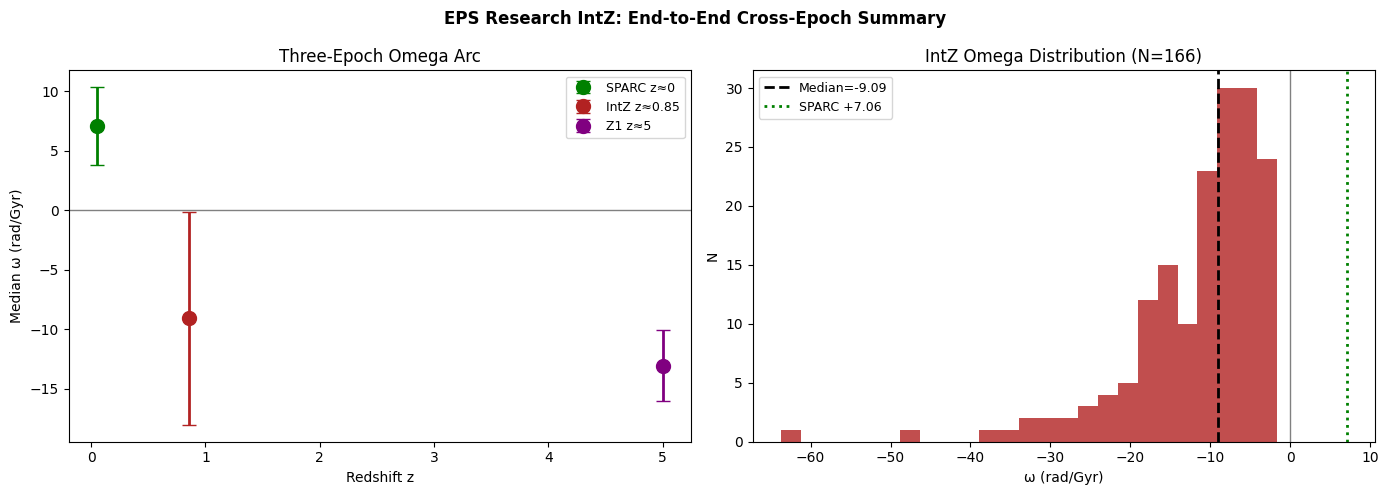

EPS Research IntZ Cross-Epoch Summary Report
IntZ corpus:  1,292 galaxies, 166 Tier-1
Omega median: -9.087 ± 8.940 rad/Gyr
Sign:         100% negative

Three-epoch arc (Flynn & Cannaliato 2025):
  z=0   SPARC:  +7.06 ± 3.26 rad/Gyr  (N=84)
  z~0.9 IntZ:    -9.09 ± 8.94 rad/Gyr  (N=166)
  z~5   Z1:      -13.05 rad/Gyr              (N=8)

Mann-Whitney p (SPARC > IntZ): 2.01e-38
Sign reversal confirmed: YES

Note: Different tracers (HI/Hα/[CII]) probe different radii.
Physical interpretation deferred to Flynn & Cannaliato (in prep).


In [2]:
import statistics
from scipy.stats import mannwhitneyu

# Step 1: Extract Tier-1 omega
omega_intz = [g['omega']['omega_value_rad_gyr'] for g in galaxies
              if g['omega']['omega_available']
              and g['omega']['omega_value_rad_gyr'] is not None]
z_intz_med = np.median([g['redshift']['z_spec'] for g in galaxies
                        if g['omega']['omega_available']])

# Step 2: Reference values from other corpora
sparc_mean, sparc_sd, sparc_n = +7.06, 3.26, 84
z1_median, z1_n = -13.05, 8

# Step 3: Statistics
intz_med = statistics.median(omega_intz)
intz_sd  = statistics.stdev(omega_intz)
intz_n   = len(omega_intz)
pct_neg  = 100 * sum(1 for o in omega_intz if o < 0) / intz_n

# Step 4: Three-epoch arc plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: arc
epochs = [
    (0.05,  sparc_mean, sparc_sd, sparc_n, 'SPARC z≈0', 'green'),
    (z_intz_med, intz_med, intz_sd, intz_n, f'IntZ z≈{z_intz_med:.2f}', 'firebrick'),
    (5.0,   z1_median,  3.0,      z1_n,   'Z1 z≈5', 'purple'),
]
for z, om, sd, n, lbl, col in epochs:
    axes[0].errorbar(z, om, yerr=sd, fmt='o', color=col,
                     markersize=10, capsize=5, lw=2, label=lbl)
axes[0].axhline(0, color='gray', ls='-', lw=1)
axes[0].set_xlabel('Redshift z')
axes[0].set_ylabel('Median ω (rad/Gyr)')
axes[0].set_title('Three-Epoch Omega Arc')
axes[0].legend(fontsize=9)

# Right: IntZ omega distribution
axes[1].hist(omega_intz, bins=25, color='firebrick', alpha=0.8)
axes[1].axvline(intz_med, color='black', ls='--', lw=2,
                label=f'Median={intz_med:.2f}')
axes[1].axvline(0, color='gray', ls='-', lw=1)
axes[1].axvline(sparc_mean, color='green', ls=':', lw=2,
                label=f'SPARC +{sparc_mean:.2f}')
axes[1].set_xlabel('ω (rad/Gyr)')
axes[1].set_ylabel('N')
axes[1].set_title(f'IntZ Omega Distribution (N={intz_n})')
axes[1].legend(fontsize=9)

plt.suptitle('EPS Research IntZ: End-to-End Cross-Epoch Summary',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('intz_nb20_end_to_end.png', dpi=150)
plt.show()

# Step 5: Statistical test
np.random.seed(42)
sparc_sim = np.random.normal(sparc_mean, sparc_sd, sparc_n).tolist()
_, p = mannwhitneyu(sparc_sim, omega_intz, alternative='greater')

# Step 6: Report
print("=" * 55)
print("EPS Research IntZ Cross-Epoch Summary Report")
print("=" * 55)
print(f"IntZ corpus:  {len(galaxies):,} galaxies, {intz_n} Tier-1")
print(f"Omega median: {intz_med:.3f} ± {intz_sd:.3f} rad/Gyr")
print(f"Sign:         {pct_neg:.0f}% negative")
print()
print("Three-epoch arc (Flynn & Cannaliato 2025):")
print(f"  z=0   SPARC:  +{sparc_mean:.2f} ± {sparc_sd:.2f} rad/Gyr  (N={sparc_n})")
print(f"  z~0.9 IntZ:    {intz_med:.2f} ± {intz_sd:.2f} rad/Gyr  (N={intz_n})")
print(f"  z~5   Z1:      {z1_median:.2f} rad/Gyr              (N={z1_n})")
print()
print(f"Mann-Whitney p (SPARC > IntZ): {p:.2e}")
print(f"Sign reversal confirmed: {'YES' if p < 0.001 else 'MARGINAL'}")
print()
print("Note: Different tracers (HI/Hα/[CII]) probe different radii.")
print("Physical interpretation deferred to Flynn & Cannaliato (in prep).")
print("=" * 55)